In [111]:
import numpy as np
import pandas as pd
import keras
import matplotlib.pyplot as plt
from keras import layers
import openpyxl as xl
from openpyxl.styles import Font
import os

In [112]:
#Coletando dados

df = pd.read_excel('/Users/PC/Documents/Proj_MPA/Recontrucao/Sergipe/4-Scombridae&afins/R.xlsx')



#Dados iniciais
df_especies = df[['Ano',"Dourado_art", "Dourado_ind"]].dropna().reset_index(drop=True)
anos_Sergipe_prever = np.array([*range(1976,1978)])

lista_de_prop=[] #lista onde ficam os arrays com as proporções Sergipe cada especie
especies = df_especies.drop('Ano',axis=1).columns.to_numpy() #lista das especies

#Coluna da soma
for i in range(len(df_especies['Ano'])):
  df_especies.loc[i,'Soma'] = df_especies.iloc[i,1:].sum() 


for k in range(len(especies)):

     dados = df_especies[['Ano',especies[k],'Soma']]
     
     #Fazendo as proporções de cada especie em relação à soma
     for i in range(len(dados['Ano'])):
       if dados.loc[i,'Soma']!=0:
           dados.loc[i,'Prop_'+especies[k]] = dados.loc[i,especies[k]] / dados.loc[i,'Soma']
     
     
     anos_com_dados = dados["Ano"].values
     todos_anos = np.concatenate((anos_Sergipe_prever, anos_com_dados))
     todos_anos.sort()
     
     prop= dados['Prop_'+especies[k]].values
     lista_de_prop.append(prop)
     print(dados.head())



    Ano  Dourado_art  Soma  Prop_Dourado_art
0  1979         16.0  17.0          0.941176
1  1980         22.0  24.0          0.916667
2  1981          6.0   7.0          0.857143
3  1982          9.0  10.0          0.900000
4  1983          3.0  12.0          0.250000
    Ano  Dourado_ind  Soma  Prop_Dourado_ind
0  1979          1.0  17.0          0.058824
1  1980          2.0  24.0          0.083333
2  1981          1.0   7.0          0.142857
3  1982          1.0  10.0          0.100000
4  1983          9.0  12.0          0.750000


In [113]:
#Normalização dos dados
ano_mean = np.mean(anos_com_dados)
ano_std = np.std(anos_com_dados)
anos_Sergipe_prever_norm = (anos_Sergipe_prever - ano_mean)/ano_std
anos_com_dados_norm = (anos_com_dados - ano_mean)/ano_std

lista_prop_norm=[]  #lista com as proporçãoes normalizads Sergipe cada especie

lista_prop_mean=[]  #listas Sergipe aplicar a inversa da normalização
lista_prop_std=[]

for k in range(len(lista_de_prop)):
    prop_mean = np.mean(lista_de_prop[k])
    prop_std = np.std(lista_de_prop[k])
    prop_norm = (lista_de_prop[k] - prop_mean)/prop_std

    lista_prop_norm.append(prop_norm)
    lista_prop_mean.append(prop_mean)
    lista_prop_std.append(prop_std)

print(lista_prop_norm)


[array([ 0.63963466,  0.54641675,  0.3200304 ,  0.48302858, -1.9891104 ]), array([-0.63963466, -0.54641675, -0.3200304 , -0.48302858,  1.9891104 ])]


In [114]:
#Criação das pastas onde serão armazenados os pesos
for esp in especies:
    folder_path = f'/Users/PC/Documents/Proj_MPA/Recontrucao/Sergipe/4-Scombridae&afins/Desagregação/Dourado_art_ind/pesos prop {esp}'
    os.makedirs(folder_path, exist_ok=True) 


#Função Sergipe fazer o Fit do modelo e salvar seus pesos Sergipe cada especie
def Fit_das_proporcoes(anos_com_dados_norm,
                       lista_prop_norm,
                       lista_de_epocas,
                       lista_de_otimizadores,
                       lista_de_overwrite,
                       especies):
    
    model = keras.Sequential([layers.Dense(96,activation='leaky_relu',input_shape=(1,)),
                                 layers.Dense(32,activation='leaky_relu'),
                                 layers.Dense(80,activation='leaky_relu'),
                                 layers.Dense(80,activation='leaky_relu'),
                                 layers.Dense(96,activation='leaky_relu'),
                                 layers.Dense(112,activation='leaky_relu'),
                                 layers.Dense(1,activation='linear')])
    
    lista_de_loss=[]
    for k in range(len(especies)):
        opt =  lista_de_otimizadores[k]            #keras.optimizers.Nadam(learning_rate=0.001)
        model.compile(optimizer=opt, loss='mse')
        
        
        history = model.fit(anos_com_dados_norm,lista_prop_norm[k], epochs=lista_de_epocas[k], verbose=0)
        lista_de_loss.append(history.history['loss'])

        
        model.save_weights(f'/Users/PC/Documents/Proj_MPA/Recontrucao/Sergipe/4-Scombridae&afins/Desagregação/Dourado_art_ind/pesos prop {especies[k]}/.weights.h5', overwrite=lista_de_overwrite[k])
    return model,lista_de_loss

In [115]:
#Fit do modelo
Nadam= keras.optimizers.Nadam(learning_rate=0.001)
Adam= keras.optimizers.Adam(learning_rate=0.001)

lista_de_epocas=[10,10,10,10,10,10,10,10,10]
lista_de_otimizadores=[Adam,Adam,Adam,Adam,Adam,Adam,Adam,Adam,Adam]
lista_de_overwrite = [True,True,True,True,True,True,True,True,True]
model,lista_de_loss = Fit_das_proporcoes(anos_com_dados_norm,
                                         lista_prop_norm,
                                         lista_de_epocas,
                                         lista_de_otimizadores,
                                         lista_de_overwrite,
                                         especies)



c:\Users\PC\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [116]:
#Previsões Sergipe cada especie
lista_de_previsoes=[]
lista_fits=[]

p = np.linspace(-2,2,50)
for k in range(len(especies)):
    
    model.load_weights(f'/Users/PC/Documents/Proj_MPA/Recontrucao/Sergipe/4-Scombridae&afins/Desagregação/Dourado_art_ind/pesos prop {especies[k]}/.weights.h5')

    prev_ausentes = model.predict(anos_Sergipe_prever_norm)*lista_prop_std[k] + lista_prop_mean[k]
    fit = model.predict(p)*lista_prop_std[k] + lista_prop_mean[k]
    #Colocando valores negativos Sergipe 0 e proporções no maximo 1
    for i in range(len(prev_ausentes)):
        if prev_ausentes[i]<0:
            prev_ausentes[i]=0
        if prev_ausentes[i]>1:
            prev_ausentes[i]=1

    lista_de_previsoes.append(prev_ausentes)
    lista_fits.append(fit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


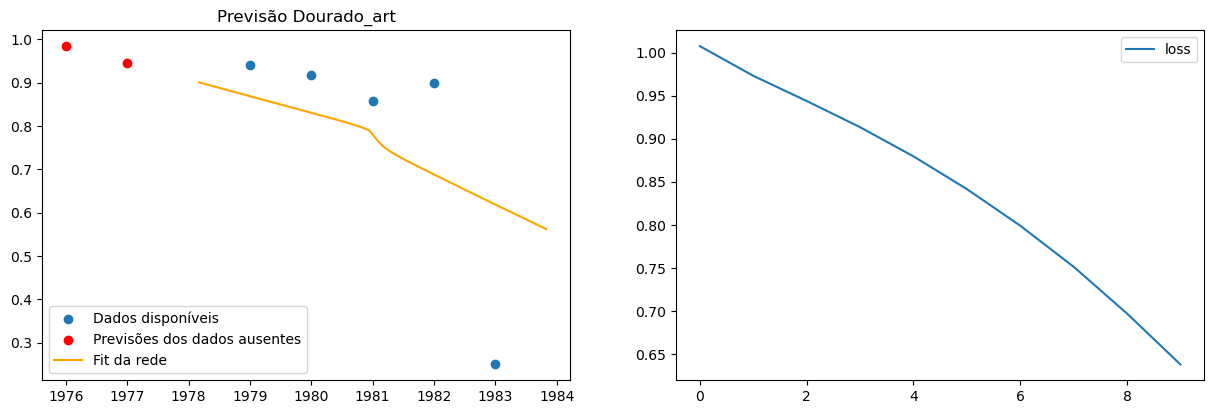

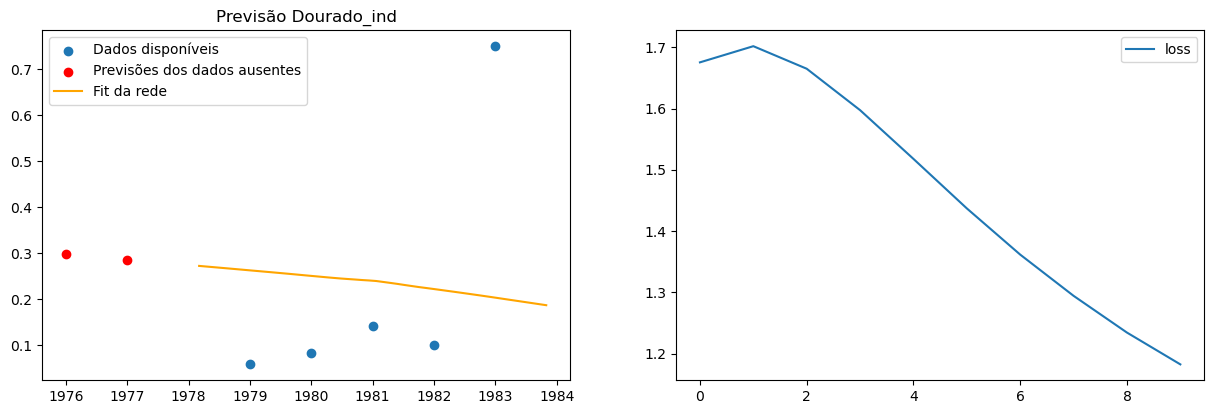

In [117]:
#Plot das previsoes e loss Sergipe cada especie
for k in range(len(especies)):
    plt.figure(figsize=(15,5*len(especies)))
    plt.subplot(len(especies),2,2*k+1 ).scatter(anos_com_dados,lista_de_prop[k],label='Dados disponíveis')
    plt.subplot(len(especies),2,2*k+1 ).scatter(anos_Sergipe_prever,lista_de_previsoes[k], color='red', label='Previsões dos dados ausentes')
    plt.subplot(len(especies),2,2*k+1 ).plot(p*ano_std + ano_mean,lista_fits[k],color='orange',label='Fit da rede')
    plt.title(f'Previsão {especies[k]}')
    plt.legend()

    plt.subplot(len(especies),2,2*k+2).plot(lista_de_loss[k],label='loss')
    plt.legend()

plt.show()

In [118]:
#Lista de anos sem buracos normalizada e sua predição      (Sergipe poder me referir por indices)
anos = np.arange(1950,np.max(anos_Sergipe_prever)+1)
anos_norm = (anos-ano_mean)/ano_std

#Previsoes sem buracos Sergipe cada especie
lista_prev_continua=[]
for k in range(len(especies)):
    model.load_weights(f'/Users/PC/Documents/Proj_MPA/Recontrucao/Sergipe/4-Scombridae&afins/Desagregação/Dourado_art_ind/pesos prop {especies[k]}/.weights.h5')
    prev_continua = model.predict(anos_norm)*lista_prop_std[k] + lista_prop_mean[k]
    
    for i in range(len(prev_continua)):
        if prev_continua[i]<0:
            prev_continua[i]=0
        if prev_continua[i]>=1:
            prev_continua[i]=1
    
    lista_prev_continua.append(prev_continua.flatten())
  


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


In [119]:
#Soma das proporções
prop_soma = np.zeros(len(anos))
for k in range(len(especies)):
    prop_soma+=lista_prev_continua[k]

#Dividindo proporções pela soma Sergipe que de sempre 1
for k in range(len(especies)):
  lista_prev_continua[k] /= prop_soma 
print(lista_prev_continua[1])

[0.37392336 0.36937237 0.3647548  0.36007106 0.3553192  0.3504963
 0.34560058 0.34063062 0.33558455 0.33046064 0.3252571  0.31997204
 0.31460354 0.3091496  0.30360812 0.2979771  0.2922542  0.2864373
 0.28052393 0.27451175 0.26839823 0.26218084 0.25585684 0.24942875
 0.2428908  0.23623523 0.2322768  0.23234485]


In [120]:
#Dicionario dos indices das espécie Sergipe prever e da que será desagregada
especies_com_desagregada = np.append(especies,"Dourado_art_ind") 
todas_colunas=df.columns.to_numpy()
dic_especies={}
for k in range(len(especies_com_desagregada)):
    for i in range(len(todas_colunas)):
        if especies_com_desagregada[k]==todas_colunas[i]:
            dic_especies[especies_com_desagregada[k]]=i+1 #Índices do openpyxl
            break
print(dic_especies)

{'Dourado_art': 15, 'Dourado_ind': 16, 'Dourado_art_ind': 17}


In [121]:
#Adicionando novos dados na planilha e colorindo
wb = xl.load_workbook('/Users/PC/Documents/Proj_MPA/Recontrucao/Sergipe/4-Scombridae&afins/R.xlsx')
ws=wb.active

for k in range(len(especies)):
    for i in range(len(anos)):
        celula=ws.cell(anos[i]-1950+2 , dic_especies[especies[k]])
        
        #Dados desagregados Sergipe células com valores mantém a cor
        if i+1950 in anos_Sergipe_prever and pd.isnull(celula.value)==False:   
          celula.value += ws.cell(anos[i]-1950+2, dic_especies["Dourado_art_ind"]).value*lista_prev_continua[k][i]
          celula.font = Font(color=celula.font.color,name='Calibri')


        #Dados desagregados Sergipe celulas vazias são colocados em vermelho
        if i+1950 in anos_Sergipe_prever and pd.isnull(celula.value)==True:
          celula.value = ws.cell(anos[i]-1950+2, dic_especies["Dourado_art_ind"]).value*lista_prev_continua[k][i]
          celula.font = Font(color='FFFF0000',name='Calibri')
          

      

wb.save('Desag_Dourado_art_ind.xlsx')